In [13]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import librosa
from sklearn.utils.class_weight import compute_class_weight
from keras.models import load_model
from keras import layers, models, callbacks, losses
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


Load features created by `feature_extraction.ipynb`


In [ ]:
feature_dir = Path('../../features/mfcc')
if not (feature_dir / 'X.npy').exists() or not (feature_dir / 'y.npy').exists():
    raise FileNotFoundError(
        f"Feature files not found in {feature_dir}. Run the preprocessing/feature_extraction notebook first to generate them."
    )
X = np.load(feature_dir / 'X.npy')
y = np.load(feature_dir / 'y.npy')


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

Plot MFCC


In [16]:
def plot_mfcc(X, i=0, save_path=None):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

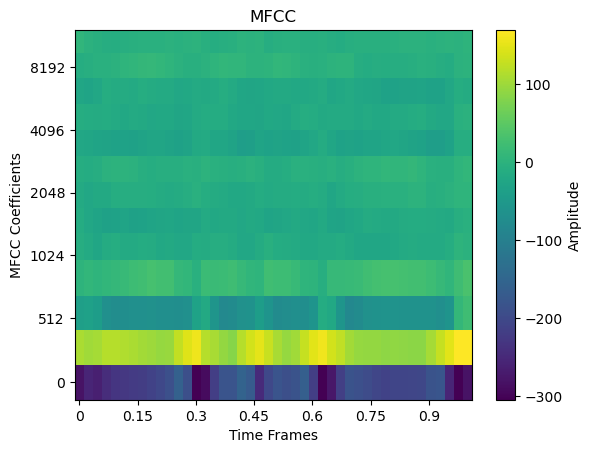

In [17]:
plot_mfcc(X, 0, '../../images/kaggle_mfcc.png')

CNN model


In [18]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 13, 44, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 22, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 22, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 22, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 22, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 11, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 11, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,248 (1.55 MB)

 Trainable params: 406,288 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

Train and save CNN (comment if only evaluating)


In [19]:
# early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

# history = cnn.fit(
#     X_train, y_train, 
#     epochs=100, 
#     validation_data=(X_val, y_val), 
#     callbacks=[early_stopping], 
#     class_weight=class_weights_dict
# )

# with open('../../histories/cnn_mfcc.pkl', 'wb') as f:
#     pickle.dump(history.history, f)

In [20]:
# cnn.save('../../models/cnn_mfcc.keras')

Load CNN


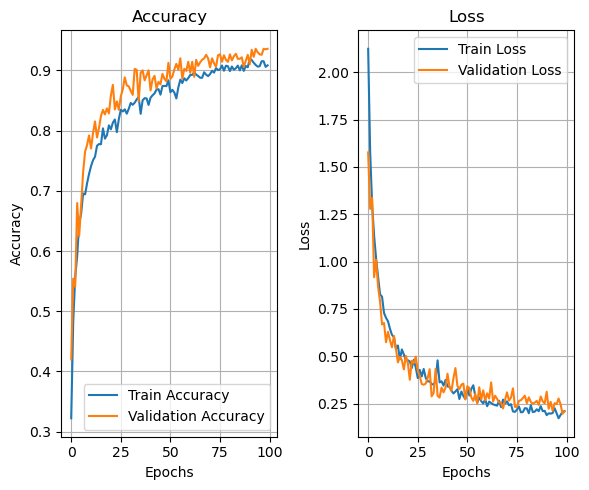

In [21]:
with open('../../histories/cnn_mfcc.pkl', 'rb') as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('../../images/cnn_mfcc_training_curves.png')
plt.show()

In [22]:
cnn = load_model('../../models/cnn_mfcc.keras')

c:\Users\grzes\anaconda3\envs\thesis\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluate CNN


In [23]:
musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

In [24]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = '../../evaluations/cnn_mfcc.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .91

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.9161118508655126

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.94      0.93      0.93        98
       Bass_drum       0.93      0.93      0.93        15
           Cello       0.83      0.95      0.89        21
        Clarinet       0.76      0.92      0.83        37
         Cowbell       0.81      0.95      0.88        63
     Double_bass       0.98      0.98      0.98        91
  Electric_piano       0.95      0.87      0.91       322
           Flute       0.91      0.95      0.93       167
    Glockenspiel       0.90      0.94      0.92       151
       Harmonica       1.00      0.93      0.96        28
          Hi-hat       0.79      0.90      0.84        71
            Oboe       0.97      0.74      0.84        95
       Saxophone       0.76      1.00      0.86        16
      Tambourine       0.96      0.96      0.96        23
         Trumpet       0.93      0.9